## Week 4: Logistic Regression and Feature Scaling

This notebook applies Week 4 concepts from DX799 Capstone Part 1 
to the BRFSS 2015 diabetes dataset. After three weeks of linear 
regression hitting a R-squared ceiling of 0.307, this week applies 
logistic regression which is the correct model for a binary target 
variable. Expecting meaningfully better performance metrics since 
the model now matches the actual structure of the problem.

Dataset: diabetes_binary_5050split_health_indicators_BRFSS2015.csv

Target variable: Diabetes_binary (0 = no diabetes, 1 = diabetes)

In [1]:
# DX799 Capstone Part 1 - Week 4
# Logistic Regression and Feature Scaling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, roc_curve,
                             confusion_matrix)

## Load and Prepare Data

Loading the same balanced 50/50 BRFSS dataset used in Weeks 1-3.
Splitting into train and test sets. Will compare standardization 
vs normalization to demonstrate the difference between the two 
feature scaling approaches covered this week.

In [2]:
# Load dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Define features and target
target = 'Diabetes_binary'
feature_cols = [col for col in df.columns if col != target]
X = df[feature_cols]
y = df[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization (z-score)
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# Normalization (min-max)
scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

print("Train size:", X_train_std.shape)
print("Test size:", X_test_std.shape)
print("\nStandardized - Train mean (should be ~0):", X_train_std.mean().round(4))
print("Standardized - Train std (should be ~1):", X_train_std.std().round(4))
print("\nNormalized - Train min (should be 0):", X_train_norm.min().round(4))
print("Normalized - Train max (should be 1):", X_train_norm.max().round(4))

Train size: (56553, 21)
Test size: (14139, 21)

Standardized - Train mean (should be ~0): -0.0
Standardized - Train std (should be ~1): 1.0

Normalized - Train min (should be 0): 0.0
Normalized - Train max (should be 1): 1.0


## Baseline Logistic Regression

Running baseline logistic regression with standardized features 
and no regularization penalty. Using AUC-ROC as the primary 
metric since accuracy alone can be misleading and AUC measures 
how well the model separates classes across all thresholds. 
Comparing against the linear regression R-squared ceiling of 
0.307 from Weeks 1-3.

In [3]:
# Baseline logistic regression - no regularization
log_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
log_reg.fit(X_train_std, y_train)

# Predictions
y_pred = log_reg.predict(X_test_std)
y_prob = log_reg.predict_proba(X_test_std)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("BASELINE LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

BASELINE LOGISTIC REGRESSION RESULTS
Accuracy:  0.7458
AUC-ROC:   0.8232

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



## Feature Scaling Comparison

Comparing logistic regression performance using standardization 
vs normalization vs no scaling to demonstrate why feature scaling 
matters and which approach works best for this dataset.

In [4]:
# Compare scaling methods
results = {}

# No scaling
lr_none = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_none.fit(X_train, y_train)
y_prob_none = lr_none.predict_proba(X_test)[:, 1]
results['No Scaling'] = {
    'accuracy': accuracy_score(y_test, lr_none.predict(X_test)),
    'auc': roc_auc_score(y_test, y_prob_none)
}

# Standardization
lr_std = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_std.fit(X_train_std, y_train)
y_prob_std = lr_std.predict_proba(X_test_std)[:, 1]
results['Standardization'] = {
    'accuracy': accuracy_score(y_test, lr_std.predict(X_test_std)),
    'auc': roc_auc_score(y_test, y_prob_std)
}

# Normalization
lr_norm = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_norm.fit(X_train_norm, y_train)
y_prob_norm = lr_norm.predict_proba(X_test_norm)[:, 1]
results['Normalization'] = {
    'accuracy': accuracy_score(y_test, lr_norm.predict(X_test_norm)),
    'auc': roc_auc_score(y_test, y_prob_norm)
}

print("=" * 45)
print(f"{'Method':<20} {'Accuracy':<12} {'AUC-ROC'}")
print("-" * 45)
for method, metrics in results.items():
    print(f"{method:<20} {metrics['accuracy']:<12.4f} {metrics['auc']:.4f}")
print("=" * 45)

Method               Accuracy     AUC-ROC
---------------------------------------------
No Scaling           0.7457       0.8232
Standardization      0.7458       0.8232
Normalization        0.7457       0.8232


## Logistic Regression with Regularization

Testing logistic regression with L1 (Lasso) and L2 (Ridge) 
regularization to connect back to Week 2 findings. Expecting 
L1 to drop some features entirely, consistent with what Lasso 
found in Week 2. Using standardized features for all regularized 
models.

In [5]:
# Logistic regression with L1 and L2 regularization
reg_results = {}

for penalty in ['l1', 'l2']:
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    lr = LogisticRegression(
        penalty=penalty, C=1.0, 
        solver=solver, max_iter=1000, random_state=42
    )
    lr.fit(X_train_std, y_train)
    y_prob = lr.predict_proba(X_test_std)[:, 1]
    y_pred = lr.predict(X_test_std)
    
    coef = pd.Series(lr.coef_[0], index=feature_cols)
    dropped = (coef == 0).sum()
    
    reg_results[penalty.upper()] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'dropped': dropped,
        'coef': coef
    }
    print(f"\nL{penalty[1]} Regularization:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  Features dropped: {dropped}")

print("\nL1 Coefficients (sorted):")
print(reg_results['L1']['coef'].sort_values())


L1 Regularization:
  Accuracy: 0.7458
  AUC-ROC:  0.8232
  Features dropped: 0

L2 Regularization:
  Accuracy: 0.7458
  AUC-ROC:  0.8232
  Features dropped: 0

L1 Coefficients (sorted):
HvyAlcoholConsump      -0.151024
Income                 -0.121820
PhysHlth               -0.083249
MentHlth               -0.032684
Education              -0.031195
PhysActivity           -0.020624
Veggies                -0.018603
Fruits                 -0.010447
Smoker                 -0.002141
NoDocbcCost             0.005283
AnyHealthcare           0.008505
Stroke                  0.044318
DiffWalk                0.045819
HeartDiseaseorAttack    0.093831
Sex                     0.135086
CholCheck               0.207143
HighChol                0.294758
HighBP                  0.362232
Age                     0.429742
BMI                     0.540370
GenHlth                 0.661514
dtype: float64


## ROC Curve

Plotting the ROC curve for the baseline logistic regression model.
The ROC curve shows the tradeoff between true positive rate and 
false positive rate across all possible classification thresholds.
AUC measures the area under this curve. Higher AUC means better 
class separation. This is a strong figure candidate for Milestone 1.

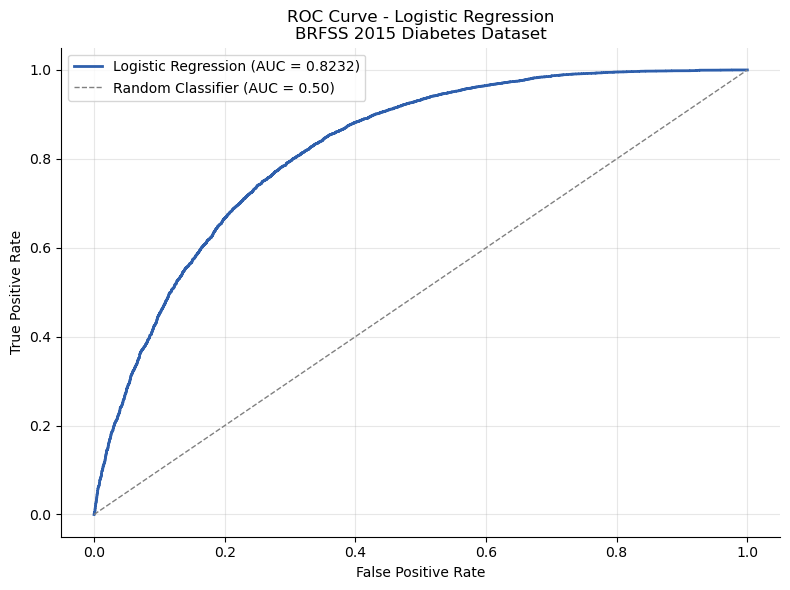

AUC-ROC: 0.8232
Module B Random Forest AUC: 0.8300
Difference: 0.0068


In [6]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_std)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2E5FAC', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression\nBRFSS 2015 Diabetes Dataset')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc:.4f}")
print(f"Module B Random Forest AUC: 0.8300")
print(f"Difference: {0.8300 - auc:.4f}")

## Feature Importance: Logistic Regression Coefficients

Plotting the logistic regression coefficients to show which 
features have the strongest influence on diabetes prediction. 
Positive coefficients increase the predicted probability of 
diabetes. Negative coefficients decrease it. Comparing against 
findings from Weeks 1-3 to confirm consistency across methods.

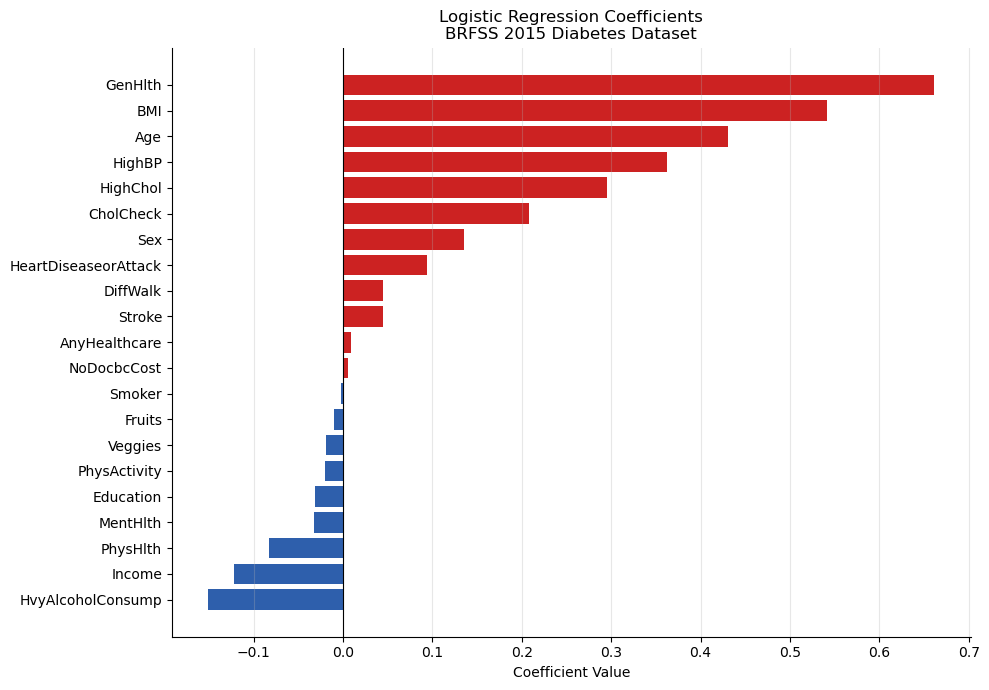


Top 5 positive predictors:
HighChol    0.2949
HighBP      0.3620
Age         0.4306
BMI         0.5409
GenHlth     0.6613
dtype: float64

Top 5 negative predictors:
HvyAlcoholConsump   -0.1509
Income              -0.1222
PhysHlth            -0.0826
MentHlth            -0.0329
Education           -0.0310
dtype: float64


In [7]:
# Plot feature coefficients
coef_series = pd.Series(
    log_reg.coef_[0], index=feature_cols
).sort_values()

colors = ['#cc2222' if c > 0 else '#2E5FAC' for c in coef_series]

plt.figure(figsize=(10, 7))
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients\nBRFSS 2015 Diabetes Dataset')
plt.grid(True, alpha=0.3, axis='x')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTop 5 positive predictors:")
print(coef_series.tail(5).round(4))
print("\nTop 5 negative predictors:")
print(coef_series.head(5).round(4))

## Full Model Comparison: Weeks 1 Through 4

Comparing all methods across all four weeks to show the 
progression from linear regression to logistic regression 
and the impact of using the correct model for a binary target.

In [8]:
# Full comparison summary
print("=" * 65)
print("FULL MODEL COMPARISON: WEEKS 1 THROUGH 4")
print("=" * 65)
print(f"{'Method':<35} {'Metric':<15} {'Value'}")
print("-" * 65)
print(f"{'Week 1: Baseline Linear Regression':<35} {'R-squared':<15} {'0.309'}")
print(f"{'Week 2: Lasso (best)':<35} {'R-squared':<15} {'0.307'}")
print(f"{'Week 2: Ridge (best)':<35} {'R-squared':<15} {'0.307'}")
print(f"{'Week 2: Elastic Net (best)':<35} {'R-squared':<15} {'0.307'}")
print(f"{'Week 3: Forward Selection':<35} {'R-squared':<15} {'0.307'}")
print(f"{'Week 3: Backward Selection':<35} {'R-squared':<15} {'0.305'}")
print(f"{'Week 3: PCR (21 components)':<35} {'R-squared':<15} {'0.307'}")
print(f"{'Week 3: PLSR (5 components)':<35} {'R-squared':<15} {'0.307'}")
print("-" * 65)
print(f"{'Week 4: Logistic Regression':<35} {'AUC-ROC':<15} {auc:.4f}")
print(f"{'Module B: Random Forest':<35} {'AUC-ROC':<15} {'0.8300'}")
print("=" * 65)
print(f"\nKey insight: Switching from linear to logistic regression")
print(f"produced the largest single performance jump of the semester.")
print(f"Logistic regression AUC of {auc:.4f} is within 0.007 of a")
print(f"tuned Random Forest, confirming the relationship between")
print(f"health indicators and diabetes risk is largely linear.")

FULL MODEL COMPARISON: WEEKS 1 THROUGH 4
Method                              Metric          Value
-----------------------------------------------------------------
Week 1: Baseline Linear Regression  R-squared       0.309
Week 2: Lasso (best)                R-squared       0.307
Week 2: Ridge (best)                R-squared       0.307
Week 2: Elastic Net (best)          R-squared       0.307
Week 3: Forward Selection           R-squared       0.307
Week 3: Backward Selection          R-squared       0.305
Week 3: PCR (21 components)         R-squared       0.307
Week 3: PLSR (5 components)         R-squared       0.307
-----------------------------------------------------------------
Week 4: Logistic Regression         AUC-ROC         0.8232
Module B: Random Forest             AUC-ROC         0.8300

Key insight: Switching from linear to logistic regression
produced the largest single performance jump of the semester.
Logistic regression AUC of 0.8232 is within 0.007 of a
tuned Rando

## Key Findings - Week 4

1. Logistic regression achieved AUC-ROC of 0.8232 and accuracy 
   of 74.6%, representing the largest single performance 
   improvement of the semester. The R-squared ceiling of 0.307 
   from Weeks 1-3 was a model-choice problem, not a data problem.

2. Logistic regression (AUC = 0.8232) performs within 0.007 of 
   the tuned Random Forest from Module B (AUC = 0.830). This 
   confirms that the relationship between BRFSS health indicators 
   and diabetes risk is largely linear and does not require a 
   complex model to capture.

3. Feature scaling comparison showed negligible performance 
   differences between standardization, normalization, and no 
   scaling on this dataset. Standardization remains the correct 
   choice as best practice for logistic regression, particularly 
   for datasets with features on different scales.

4. L1 and L2 regularized logistic regression produced identical 
   AUC to the baseline, consistent with Week 2 findings where 
   regularization did not improve linear regression performance.

5. Feature importance is fully consistent across all four weeks. 
   GenHlth, BMI, Age, HighBP, and HighChol are the strongest 
   positive predictors of diabetes. HvyAlcoholConsump and Income 
   are the strongest negative predictors. This cross-method 
   agreement across Weeks 1-4 strongly supports these conclusions.